**MACHINE LEARNING HACKATHON**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('train_dataset.csv') # data

In [ ]:
df.shape

(150, 6)

In [ ]:
df.describe()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,40.466800,2.311333,424.423400,14.086533,442.240800,36.222173
std,22.239772,1.019844,45.200641,6.995343,55.047768,38.427427
min,5.410000,0.520000,351.630000,2.260000,354.010000,0.000000
25%,21.112500,1.362500,387.255000,8.027500,393.327500,0.013500
50%,38.610000,2.445000,425.630000,14.235000,437.080000,15.314000
75%,61.227500,3.155000,462.972500,20.685000,486.180000,74.876500
max,79.020000,3.970000,498.580000,24.990000,547.990000,99.971000


In [ ]:
df.head()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
pip install -U ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00


# PANDA PROFILING

In [ ]:
import pandas as pd
from ydata_profiling import ProfileReport

df = pd.read_csv('/content/train_dataset.csv')

profile = ProfileReport(df, title="Pandas Profiling Report")

profile.to_file("report.html")

/tmp/ipykernel_2822/405106741.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 78.96it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
from google.colab import files

files.download("report.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.isnull().sum()

,0
flow_rate_L_min,0
concentration_mol_L,0
inlet_temperature_K,0
length_m,0
jacket_temperature_K,0
overall_yield,0


In [ ]:
df.columns

Index(['flow_rate_L_min', 'concentration_mol_L', 'inlet_temperature_K',
       'length_m', 'jacket_temperature_K', 'overall_yield'],
      dtype='object')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

# Train Test Split


In [ ]:
X = df.drop(columns="overall_yield")
y = df["overall_yield"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LINEAR REGRESSION. (First Model)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE",rmse)
print(" R2 ", r2)



RMSE 31.423627067386263
 R2  0.4384425392263346


# RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=235,
    max_depth=7,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.8,
    bootstrap=True,
    max_samples=0.9,
    criterion="squared_error",
    random_state=42,
    n_jobs=-1)
rfr.fit(X_train, y_train)
y_pred = rfr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE",rmse)
print(" R2 ", r2)

RMSE 22.039397661480656
 R2  0.7237635273538244


# DECISION TREE REGRESSOR

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(
    max_depth=4,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE",rmse)
print(" R2 ", r2)

RMSE 28.750300268428756
 R2  0.5299258739361761


# GRADIENT BOOSTING REGRESSOR

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE",rmse)
print(" R2 ", r2)



RMSE 24.159038709855146
 R2  0.6680743021432194


# XG BOOST REGRESSOR

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE",rmse)
print(" R2 ", r2)


RMSE 24.159038709855146
 R2  0.6680743021432194


# SVR

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

svr = make_pipeline(
    StandardScaler(),
    SVR(
        C=100,
        epsilon=0.1,
        kernel="rbf"
    )
)

svr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE",rmse)
print(" R2 ", r2)


RMSE 24.159038709855146
 R2  0.6680743021432194


# KNN REGRESSOR

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

knn = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(
        n_neighbors=5,
        weights="distance"
    )
)

knn.fit(X_train, y_train)
y_pred = gbr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("RMSE",rmse)
print(" R2 ", r2)


RMSE 24.159038709855146
 R2  0.6680743021432194


In [ ]:
df.shape


(150, 6)

In [ ]:

df.describe()

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,40.466800,2.311333,424.423400,14.086533,442.240800,36.222173
std,22.239772,1.019844,45.200641,6.995343,55.047768,38.427427
min,5.410000,0.520000,351.630000,2.260000,354.010000,0.000000
25%,21.112500,1.362500,387.255000,8.027500,393.327500,0.013500
50%,38.610000,2.445000,425.630000,14.235000,437.080000,15.314000
75%,61.227500,3.155000,462.972500,20.685000,486.180000,74.876500
max,79.020000,3.970000,498.580000,24.990000,547.990000,99.971000


In [ ]:
pd.Series(df.columns)

,0
0,flow_rate_L_min
1,concentration_mol_L
2,inlet_temperature_K
3,length_m
4,jacket_temperature_K
5,overall_yield


In [ ]:
df

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield
0,33.09,3.68,357.75,19.87,383.79,63.024
1,76.30,1.34,429.70,14.84,405.72,86.611
2,59.90,1.01,431.10,11.76,385.40,86.347
3,49.90,2.21,445.61,22.85,367.74,92.175
4,16.70,3.95,458.91,4.56,374.13,82.211
...,...,...,...,...,...,...
145,7.77,2.33,492.09,12.90,529.91,0.000
146,50.72,3.19,497.90,17.35,426.78,1.249
147,42.70,1.26,463.01,5.96,458.71,0.645
148,8.86,2.68,406.44,6.42,531.29,0.000


# NEW FEATURES ADDED

In [ ]:
# features_new_01 : temp difference
df["temperature_difference"] = (
    df["inlet_temperature_K"] - df["jacket_temperature_K"]
)

In [ ]:
# features_new_02 : temp difference
df["reference_time"] = (
    df["length_m"]/df["flow_rate_L_min"]
)

In [ ]:
# feature no 3: arrhenius
df["Arrhenius_Inlet"] = np.exp(
    -1 / df["temperature_difference"]
)

In [ ]:
# feature no 4: arrhenius
df["molar_feed_rate"] = (
    df["flow_rate_L_min"] * df["concentration_mol_L"]
)

In [ ]:
# feature no 5: arrhenius
df["molar_feed_rate_time"] = (
    df["flow_rate_L_min"] * df["concentration_mol_L"]
)

In [ ]:
# feature no 6: arrhenius
df["interection"] = (
    df["reference_time"] * df["inlet_temperature_K"]
)

In [ ]:
df["reference_time_square"] = (
    (df["length_m"]/df["flow_rate_L_min"])**2
)

In [ ]:
df['inlet_temp_sq'] = df['inlet_temperature_K'] ** 2

In [ ]:
df.drop(columns=["molar_feed_rate"], inplace=True)

In [ ]:
df

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield,temperature_difference,reference_time,Arrhenius_Inlet,molar_feed_rate_time,interection,reference_time_square,inlet_temp_sq
0,33.09,3.68,357.75,19.87,383.79,63.024,-26.04,0.600484,1.039149,19.87,214.822983,0.360580,127985.0625
1,76.30,1.34,429.70,14.84,405.72,86.611,23.98,0.194495,0.959156,14.84,83.574679,0.037828,184642.0900
2,59.90,1.01,431.10,11.76,385.40,86.347,45.70,0.196327,0.978356,11.76,84.636661,0.038544,185847.2100
3,49.90,2.21,445.61,22.85,367.74,92.175,77.87,0.457916,0.987240,22.85,204.051874,0.209687,198568.2721
4,16.70,3.95,458.91,4.56,374.13,82.211,84.78,0.273054,0.988274,4.56,125.307162,0.074558,210598.3881
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,7.77,2.33,492.09,12.90,529.91,0.000,-37.82,1.660232,1.026794,12.90,816.983398,2.756369,242152.5681
146,50.72,3.19,497.90,17.35,426.78,1.249,71.12,0.342074,0.986038,17.35,170.318711,0.117015,247904.4100
147,42.70,1.26,463.01,5.96,458.71,0.645,4.30,0.139578,0.792504,5.96,64.626220,0.019482,214378.2601
148,8.86,2.68,406.44,6.42,531.29,0.000,-124.85,0.724605,1.008042,6.42,294.508442,0.525052,165193.4736


In [ ]:
correlation = df["inlet_temp_sq"].corr(
    df["overall_yield"]
)

print("Correlation:", correlation)

Correlation: -0.4187475259991487


# POLYNOMIAL REGRESION

In [ ]:
X = df.iloc[:, [0]]
y = df["overall_yield"]

In [ ]:
df


,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield,temperature_difference,reference_time,Arrhenius_Inlet,molar_feed_rate_time,interection,reference_time_square,inlet_temp_sq
0,33.09,3.68,357.75,19.87,383.79,63.024,-26.04,0.600484,1.039149,19.87,214.822983,0.360580,127985.0625
1,76.30,1.34,429.70,14.84,405.72,86.611,23.98,0.194495,0.959156,14.84,83.574679,0.037828,184642.0900
2,59.90,1.01,431.10,11.76,385.40,86.347,45.70,0.196327,0.978356,11.76,84.636661,0.038544,185847.2100
3,49.90,2.21,445.61,22.85,367.74,92.175,77.87,0.457916,0.987240,22.85,204.051874,0.209687,198568.2721
4,16.70,3.95,458.91,4.56,374.13,82.211,84.78,0.273054,0.988274,4.56,125.307162,0.074558,210598.3881
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,7.77,2.33,492.09,12.90,529.91,0.000,-37.82,1.660232,1.026794,12.90,816.983398,2.756369,242152.5681
146,50.72,3.19,497.90,17.35,426.78,1.249,71.12,0.342074,0.986038,17.35,170.318711,0.117015,247904.4100
147,42.70,1.26,463.01,5.96,458.71,0.645,4.30,0.139578,0.792504,5.96,64.626220,0.019482,214378.2601
148,8.86,2.68,406.44,6.42,531.29,0.000,-124.85,0.724605,1.008042,6.42,294.508442,0.525052,165193.4736


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

degree = 2   # ← bas is number ko change karo

poly_model = make_pipeline(
    PolynomialFeatures(degree=degree, include_bias=False),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

y_pred = poly_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Degree:", degree)
print("RMSE:", rmse)
print("R2:", r2)

Degree: 2
RMSE: 29.57569317213266
R2: 0.5025477015908375


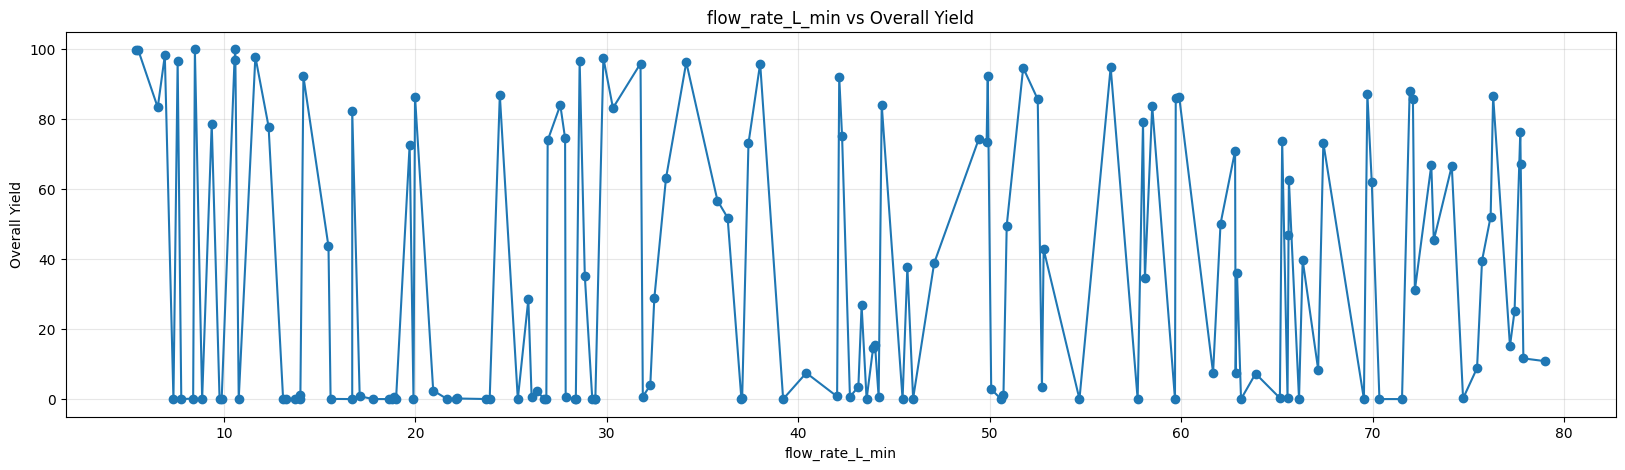

In [ ]:
feature = "flow_rate_L_min"

temp = df[[feature, "overall_yield"]].sort_values(feature)

x = temp[feature].values
y = temp["overall_yield"].values

plt.figure(figsize=(20, 5))

plt.plot(x, y, marker="o")

plt.xlabel(feature)
plt.ylabel("Overall Yield")
plt.title(f"{feature} vs Overall Yield")

plt.grid(True, alpha=0.3)
plt.show()

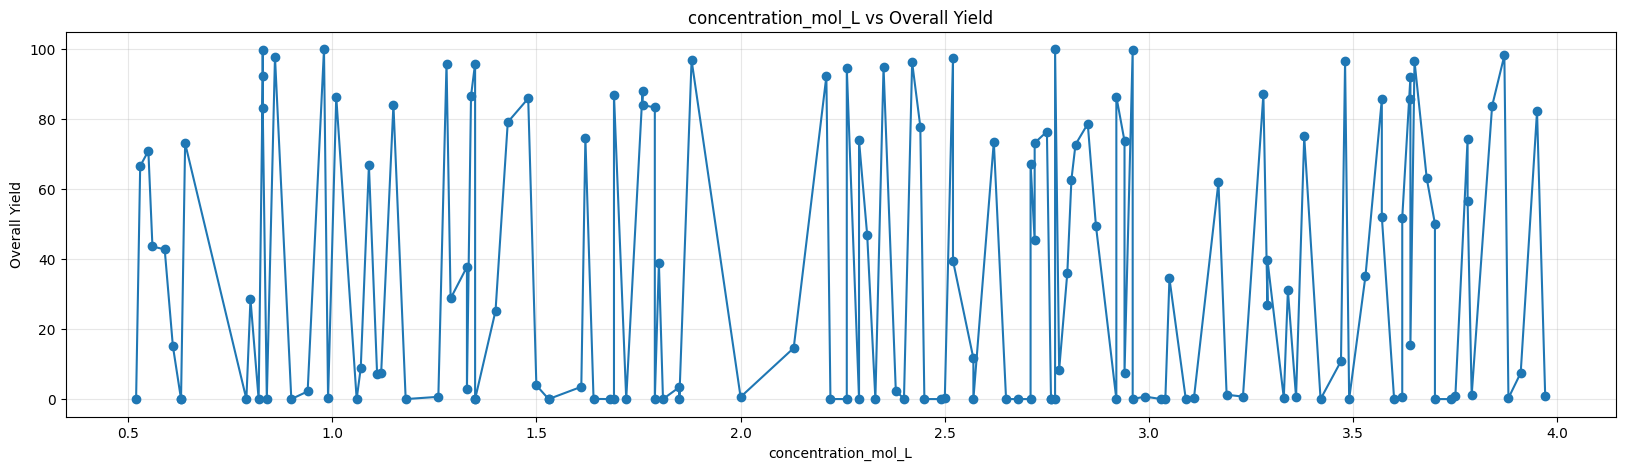

In [ ]:
feature = "concentration_mol_L"

temp = df[[feature, "overall_yield"]].sort_values(feature)

x = temp[feature].values
y = temp["overall_yield"].values

plt.figure(figsize=(20, 5))

plt.plot(x, y, marker="o")

plt.xlabel(feature)
plt.ylabel("Overall Yield")
plt.title(f"{feature} vs Overall Yield")

plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
inlet_temperature_K	length_m	jacket_temperature_K

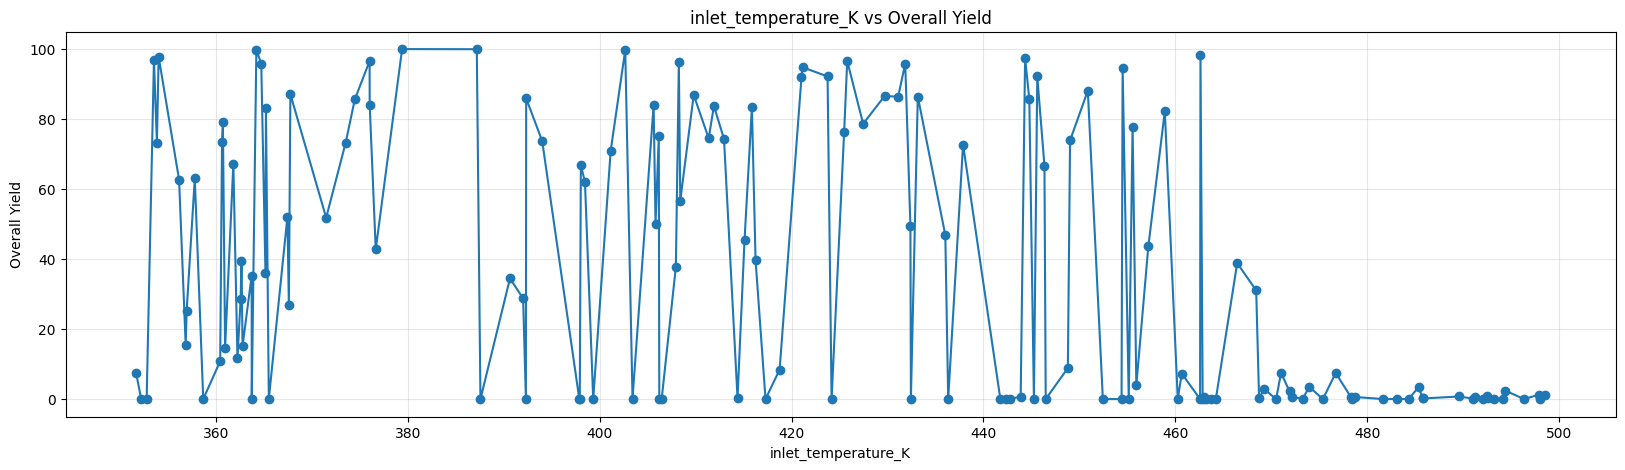

In [ ]:
feature = "inlet_temperature_K"

temp = df[[feature, "overall_yield"]].sort_values(feature)

x = temp[feature].values
y = temp["overall_yield"].values

plt.figure(figsize=(20, 5))

plt.plot(x, y, marker="o")

plt.xlabel(feature)
plt.ylabel("Overall Yield")
plt.title(f"{feature} vs Overall Yield")

plt.grid(True, alpha=0.3)
plt.show()

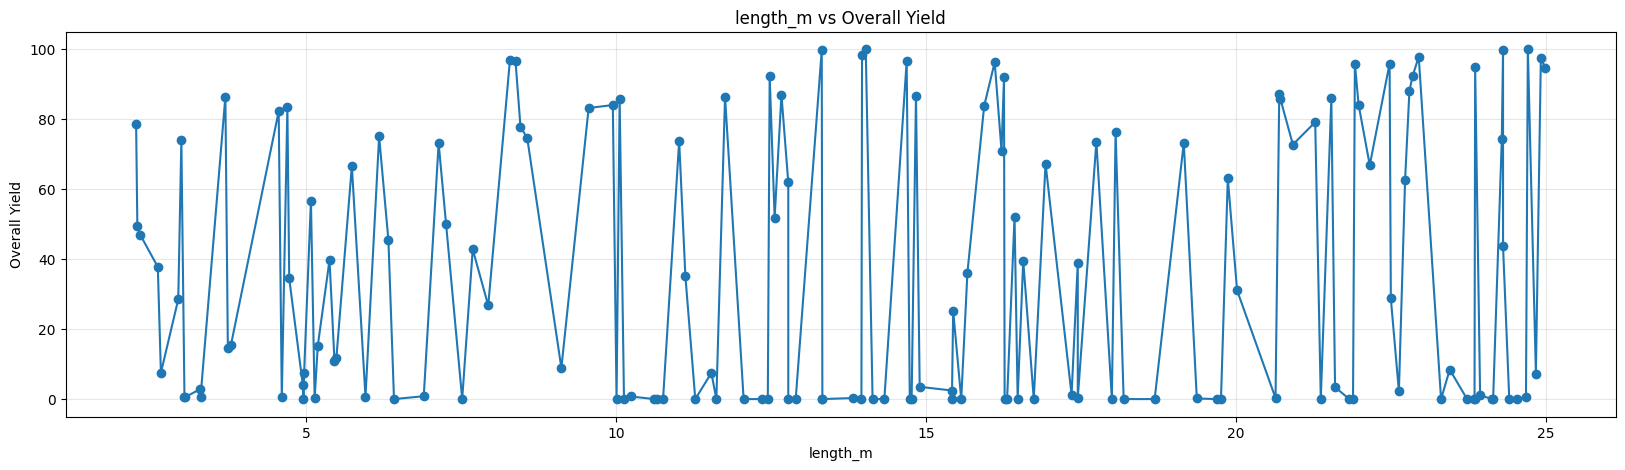

In [ ]:
feature = "length_m"

temp = df[[feature, "overall_yield"]].sort_values(feature)

x = temp[feature].values
y = temp["overall_yield"].values

plt.figure(figsize=(20, 5))

plt.plot(x, y, marker="o")

plt.xlabel(feature)
plt.ylabel("Overall Yield")
plt.title(f"{feature} vs Overall Yield")

plt.grid(True, alpha=0.3)
plt.show()

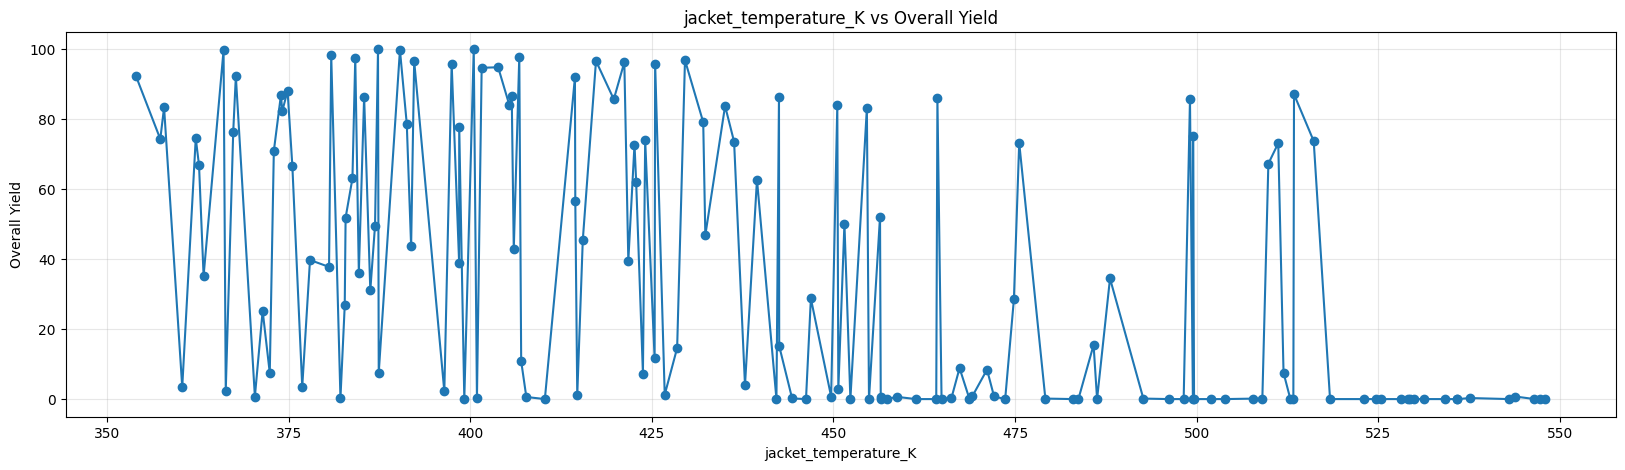

In [ ]:
feature = "jacket_temperature_K"

temp = df[[feature, "overall_yield"]].sort_values(feature)

x = temp[feature].values
y = temp["overall_yield"].values

plt.figure(figsize=(20, 5))

plt.plot(x, y, marker="o")

plt.xlabel(feature)
plt.ylabel("Overall Yield")
plt.title(f"{feature} vs Overall Yield")

plt.grid(True, alpha=0.3)
plt.show()

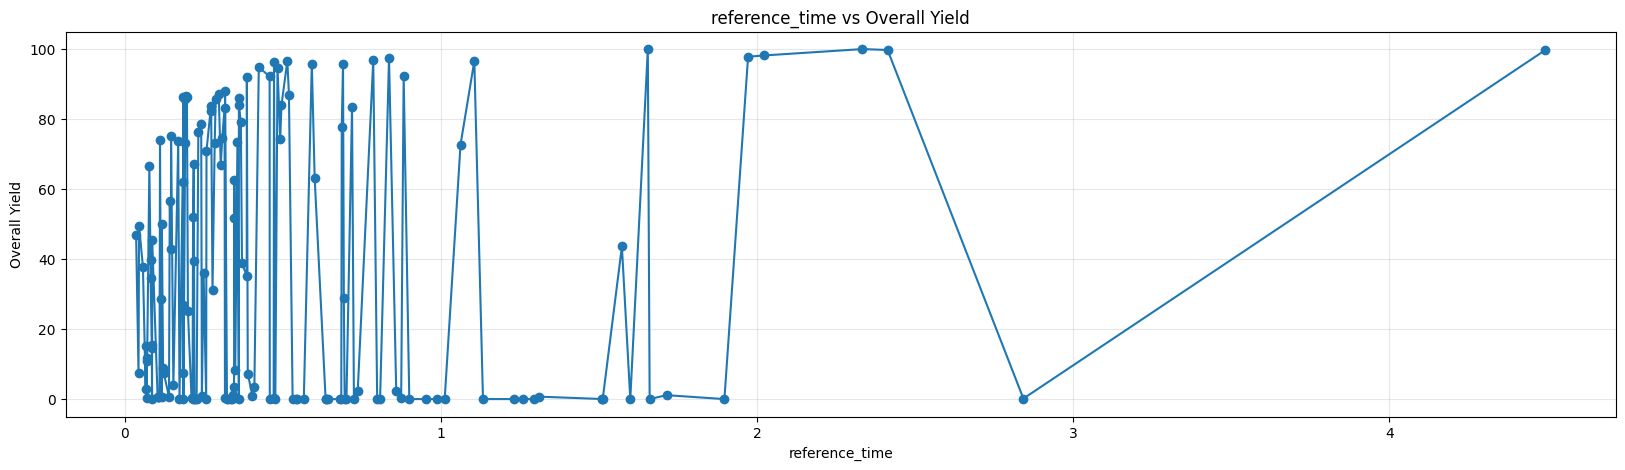

In [ ]:
# reference_time

feature = "reference_time"

temp = df[[feature, "overall_yield"]].sort_values(feature)

x = temp[feature].values
y = temp["overall_yield"].values

plt.figure(figsize=(20, 5))

plt.plot(x, y, marker="o")

plt.xlabel(feature)
plt.ylabel("Overall Yield")
plt.title(f"{feature} vs Overall Yield")

plt.grid(True, alpha=0.3)
plt.show()

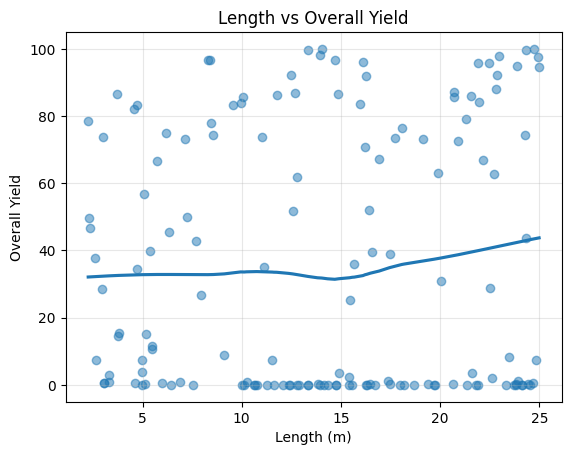

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    x="length_m",
    y="overall_yield",
    data=df,
    lowess=True,
    scatter_kws={"alpha": 0.5},
    line_kws={}
)

plt.xlabel("Length (m)")
plt.ylabel("Overall Yield")
plt.title("Length vs Overall Yield")
plt.grid(True, alpha=0.3)
plt.show()

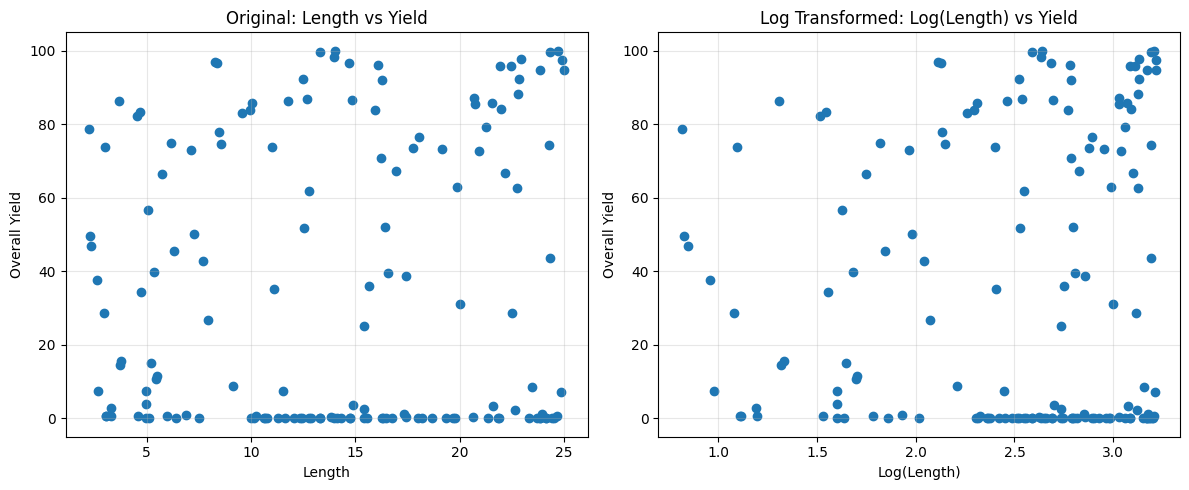

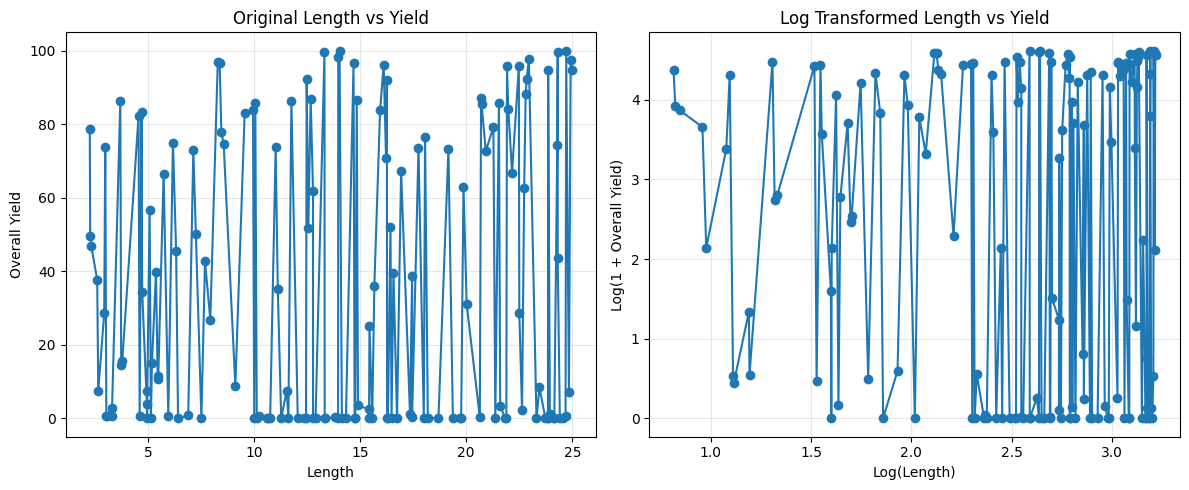

In [ ]:
feature = "length_m"

temp = df[[feature, "overall_yield"]].sort_values(feature)

x = temp[feature].values
y = temp["overall_yield"].values

x_log = np.log(x)
y_log = np.log1p(y)


plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
plt.plot(x, y, marker="o")
plt.xlabel("Length")
plt.ylabel("Overall Yield")
plt.title("Original Length vs Yield")
plt.grid(True, alpha=0.3)

# Both log transformed
plt.subplot(1, 2, 2)
plt.plot(x_log, y_log, marker="o")
plt.xlabel("Log(Length)")
plt.ylabel("Log(1 + Overall Yield)")
plt.title("Log Transformed Length vs Yield")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df

,flow_rate_L_min,concentration_mol_L,inlet_temperature_K,length_m,jacket_temperature_K,overall_yield,temperature_difference,reference_time,Arrhenius_Inlet,molar_feed_rate_time,interection,reference_time_square,inlet_temp_sq
0,33.09,3.68,357.75,19.87,383.79,63.024,-26.04,0.600484,1.039149,19.87,214.822983,0.360580,127985.0625
1,76.30,1.34,429.70,14.84,405.72,86.611,23.98,0.194495,0.959156,14.84,83.574679,0.037828,184642.0900
2,59.90,1.01,431.10,11.76,385.40,86.347,45.70,0.196327,0.978356,11.76,84.636661,0.038544,185847.2100
3,49.90,2.21,445.61,22.85,367.74,92.175,77.87,0.457916,0.987240,22.85,204.051874,0.209687,198568.2721
4,16.70,3.95,458.91,4.56,374.13,82.211,84.78,0.273054,0.988274,4.56,125.307162,0.074558,210598.3881
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,7.77,2.33,492.09,12.90,529.91,0.000,-37.82,1.660232,1.026794,12.90,816.983398,2.756369,242152.5681
146,50.72,3.19,497.90,17.35,426.78,1.249,71.12,0.342074,0.986038,17.35,170.318711,0.117015,247904.4100
147,42.70,1.26,463.01,5.96,458.71,0.645,4.30,0.139578,0.792504,5.96,64.626220,0.019482,214378.2601
148,8.86,2.68,406.44,6.42,531.29,0.000,-124.85,0.724605,1.008042,6.42,294.508442,0.525052,165193.4736


In [ ]:
df_new = df[
    [

        "concentration_mol_L",

        "length_m",
        "flow_rate_L_min",
        "inlet_temperature_K",
        "jacket_temperature_K",



        "interection",
        "reference_time_square",
        "inlet_temp_sq",
        "overall_yield"
    ]
]

In [ ]:
df_new["temperature_difference"] = (
    df_new["inlet_temperature_K"] -
    df_new["jacket_temperature_K"]
)

df_new["abs_temperature_difference"] = (
    df_new["inlet_temperature_K"] -
    df_new["jacket_temperature_K"]
).abs()

df_new["temperature_ratio"] = (
    df_new["inlet_temperature_K"] /
    df_new["jacket_temperature_K"]
)

df_new["length_flow_ratio"] = (
    df_new["length_m"] /
    df_new["flow_rate_L_min"]
)

df_new["flow_length_ratio"] = (
    df_new["flow_rate_L_min"] /
    df_new["length_m"]
)

df_new["flow_concentration"] = (
    df_new["flow_rate_L_min"] *
    df_new["concentration_mol_L"]
)

df_new["concentration_inlet_temp"] = (
    df_new["concentration_mol_L"] *
    df_new["inlet_temperature_K"]
)

df_new["flow_inlet_temp"] = (
    df_new["flow_rate_L_min"] *
    df_new["inlet_temperature_K"]
)

df_new["length_inlet_temp"] = (
    df_new["length_m"] *
    df_new["inlet_temperature_K"]
)

df_new["inlet_jacket_product"] = (
    df_new["inlet_temperature_K"] *
    df_new["jacket_temperature_K"]
)

/tmp/ipykernel_2822/3623527037.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["temperature_difference"] = (
/tmp/ipykernel_2822/3623527037.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new["abs_temperature_difference"] = (
/tmp/ipykernel_2822/3623527037.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stabl

In [ ]:
df_new

,concentration_mol_L,length_m,flow_rate_L_min,inlet_temperature_K,jacket_temperature_K,interection,reference_time_square,inlet_temp_sq,overall_yield,temperature_difference,abs_temperature_difference,length_flow_ratio,flow_concentration,concentration_inlet_temp,flow_inlet_temp,length_inlet_temp
0,3.68,19.87,33.09,357.75,383.79,214.822983,0.360580,127985.0625,63.024,-26.04,26.04,0.600484,121.7712,1316.5200,11837.9475,7108.4925
1,1.34,14.84,76.30,429.70,405.72,83.574679,0.037828,184642.0900,86.611,23.98,23.98,0.194495,102.2420,575.7980,32786.1100,6376.7480
2,1.01,11.76,59.90,431.10,385.40,84.636661,0.038544,185847.2100,86.347,45.70,45.70,0.196327,60.4990,435.4110,25822.8900,5069.7360
3,2.21,22.85,49.90,445.61,367.74,204.051874,0.209687,198568.2721,92.175,77.87,77.87,0.457916,110.2790,984.7981,22235.9390,10182.1885
4,3.95,4.56,16.70,458.91,374.13,125.307162,0.074558,210598.3881,82.211,84.78,84.78,0.273054,65.9650,1812.6945,7663.7970,2092.6296
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,2.33,12.90,7.77,492.09,529.91,816.983398,2.756369,242152.5681,0.000,-37.82,37.82,1.660232,18.1041,1146.5697,3823.5393,6347.9610
146,3.19,17.35,50.72,497.90,426.78,170.318711,0.117015,247904.4100,1.249,71.12,71.12,0.342074,161.7968,1588.3010,25253.4880,8638.5650
147,1.26,5.96,42.70,463.01,458.71,64.626220,0.019482,214378.2601,0.645,4.30,4.30,0.139578,53.8020,583.3926,19770.5270,2759.5396
148,2.68,6.42,8.86,406.44,531.29,294.508442,0.525052,165193.4736,0.000,-124.85,124.85,0.724605,23.7448,1089.2592,3601.0584,2609.3448


In [ ]:
df_new = df_new.drop(columns=[
    "flow_rate_L_min",
    "concentration_mol_L",
    "inlet_temperature_K",
    "length_m",
    "jacket_temperature_K"
])

In [ ]:
df_new["temperature_difference"] = (
    df_new["inlet_temperature_K"] -
    df_new["jacket_temperature_K"]
)

df_new["abs_temperature_difference"] = (
    df_new["inlet_temperature_K"] -
    df_new["jacket_temperature_K"]
).abs()

df_new["temperature_ratio"] = (
    df_new["inlet_temperature_K"] /
    df_new["jacket_temperature_K"]
)

In [ ]:
X_new = df_new.drop(columns="overall_yield")
y_new = df_new["overall_yield"]

X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=235,
    max_depth=7,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.8,
    bootstrap=True,
    max_samples=0.9,
    criterion="squared_error",
    random_state=42,
    n_jobs=-1)
rfr.fit(X_new_train, y_new_train)
y_new_pred = rfr.predict(X_new_test)
r2 = r2_score(y_new_test, y_new_pred)
rmse = root_mean_squared_error(y_new_test, y_new_pred)

print("RMSE",rmse)
print(" R2 ", r2)

RMSE 18.616294045635406
 R2  0.8029084351261387


In [ ]:
rfr.fit(X_new_train, y_new_train)

train_pred = rfr.predict(X_new_train)
test_pred = rfr.predict(X_new_test)

train_rmse = root_mean_squared_error(y_new_train, train_pred)
test_rmse = root_mean_squared_error(y_new_test, test_pred)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 10.700200317040597
Test RMSE: 18.616294045635406


In [ ]:
from sklearn.model_selection import KFold, cross_val_score

X = df_new.drop(columns=["overall_yield"])
y = df_new["overall_yield"]

rfr = RandomForestRegressor(
    n_estimators=235,
    max_depth=4,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features=0.8,
    bootstrap=True,
    max_samples=0.9,
    criterion="squared_error",
    random_state=42,
    n_jobs=-1
)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rfr,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print("RMSE of each fold:", rmse_scores)
print("Mean CV RMSE:", rmse_scores.mean())
print("Std CV RMSE:", rmse_scores.std())

RMSE of each fold: [19.51087711 22.65841447 22.67729853 17.29143715 22.58898367]
Mean CV RMSE: 20.94540218659135
Std CV RMSE: 2.1929231083398113


In [ ]:
# ==============================
# THERMAL FEATURES
# ==============================

df_new["delta_T"] = (
    df_new["inlet_temperature_K"]
    - df_new["jacket_temperature_K"]
)

df_new["abs_delta_T"] = (
    df_new["delta_T"].abs()
)

df_new["T_mean"] = (
    df_new["inlet_temperature_K"]
    + df_new["jacket_temperature_K"]
) / 2

df_new["T_ratio"] = (
    df_new["inlet_temperature_K"]
    / df_new["jacket_temperature_K"]
)


# ==============================
# ARRHENIUS-INSPIRED FEATURES
# ==============================

df_new["inv_T_inlet"] = (
    1 / df_new["inlet_temperature_K"]
)

df_new["inv_T_jacket"] = (
    1 / df_new["jacket_temperature_K"]
)

df_new["inv_T_delta"] = (
    df_new["inv_T_inlet"]
    - df_new["inv_T_jacket"]
)

df_new["arrhenius_inlet"] = np.exp(
    -1 / df_new["inlet_temperature_K"]
)

df_new["arrhenius_jacket"] = np.exp(
    -1 / df_new["jacket_temperature_K"]
)


# ==============================
# RESIDENCE TIME PROXY
# ==============================

df_new["residence_time_proxy"] = (
    df_new["length_m"]
    / df_new["flow_rate_L_min"]
)


# ==============================
# REACTION EXPOSURE
# ==============================

df_new["thermal_residence_proxy"] = (
    df_new["residence_time_proxy"]
    * df_new["arrhenius_inlet"]
)

df_new["thermal_exposure"] = (
    df_new["residence_time_proxy"]
    * df_new["delta_T"]
)


# ==============================
# CONCENTRATION
# ==============================

df_new["log_concentration"] = np.log(
    df_new["concentration_mol_L"]
)

df_new["inv_concentration"] = (
    1 / df_new["concentration_mol_L"]
)

df_new["concentration_exposure"] = (
    df_new["concentration_mol_L"]
    * df_new["residence_time_proxy"]
)

# So far, we had created a lot of features, but the results we were getting were not as good as we expected. After reading the problem statement, we understood that feature engineering would be one of the most important parts of this problem. That is why we kept trying different new features, but eventually we had created so many features that we ourselves became confused. We also tried various things such as visualization and other approaches. Finally, we created a new notebook in Jupyter Notebook and continued our work there.
.